In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
camp_df = pd.read_csv("Camp.csv")
makaha_df = pd.read_csv("Makaha.csv")
opaeula_df = pd.read_csv("Opaeula.csv")
tantalus_df = pd.read_csv("Tantalus.csv")
waialua_df = pd.read_csv("Waialua.csv")

/var/folders/yh/xwyc6y5d3x9cfr4vbk_72mb00000gn/T/ipykernel_19791/401056248.py:1: DtypeWarning: Columns (9,14,19,24,29,34,39,44,49,54,59,64,69,74,79,84,89,94,99,104,109,114,119,124) have mixed types. Specify dtype option on import or set low_memory=False.
  camp_df = pd.read_csv("Camp.csv")
/var/folders/yh/xwyc6y5d3x9cfr4vbk_72mb00000gn/T/ipykernel_19791/401056248.py:2: DtypeWarning: Columns (9,14,19,24,29,34,39,44,49,54,59,64,69,74,79,84,89,94,99,104,109,114,119,124) have mixed types. Specify dtype option on import or set low_memory=False.
  makaha_df = pd.read_csv("Makaha.csv")
/var/folders/yh/xwyc6y5d3x9cfr4vbk_72mb00000gn/T/ipykernel_19791/401056248.py:3: DtypeWarning: Columns (9,14,19,24,29,34,39,44,49,54,59,64,69,74,79,84,89,94,99,104,109,114,119,124) have mixed types. Specify dtype option on import or set low_memory=False.
  opaeula_df = pd.read_csv("Opaeula.csv")
/var/folders/yh/xwyc6y5d3x9cfr4vbk_72mb00000gn/T/ipykernel_19791/401056248.py:5: DtypeWarning: Columns (9,14,19,24,29

In [35]:
#Clean 
rain_dfs = [camp_df, makaha_df, opaeula_df, tantalus_df, waialua_df]
for i in range(len(rain_dfs)):
    df = rain_dfs[i]
    df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
    df['DlySum'] = pd.to_numeric(df['DlySum'], errors='coerce')
    df.dropna(subset=['DATE', 'DlySum'], inplace=True)
    df = df[df['DlySum'] >= 0]
    rain_dfs[i] = df

In [38]:
# Combine rainfall
combined_rainfall = pd.concat(rain_dfs, ignore_index=True)
daily_rainfall = combined_rainfall.groupby('DATE')['DlySum'].sum().reset_index()


In [40]:
#clean Enterococcus
enterococcus_df = pd.read_csv("Kaupuni(Main).csv")
enterococcus_df['collection date'] = pd.to_datetime(enterococcus_df['collection date'], errors='coerce')
enterococcus_df['Enterococcus (mpn/100mL)'] = pd.to_numeric(enterococcus_df['Enterococcus (mpn/100mL)'], errors='coerce')
enterococcus_cleaned = enterococcus_df[['collection date', 'Enterococcus (mpn/100mL)']].dropna()
enterococcus_cleaned.rename(columns={'collection date': 'DATE'}, inplace=True)

In [42]:
#Merge date
merged_df = pd.merge(enterococcus_cleaned, daily_rainfall, on='DATE', how='inner')
merged_df['Month'] = merged_df['DATE'].dt.month_name()

# Aggregate by month
bubble_data_all_rain = merged_df.groupby('Month').agg({
    'DlySum': 'mean',
    'Enterococcus (mpn/100mL)': 'mean'
}).reset_index()
bubble_data_all_rain['MonthOrder'] = pd.to_datetime(bubble_data_all_rain['Month'], format='%B').dt.month
bubble_data_all_rain.sort_values('MonthOrder', inplace=True)

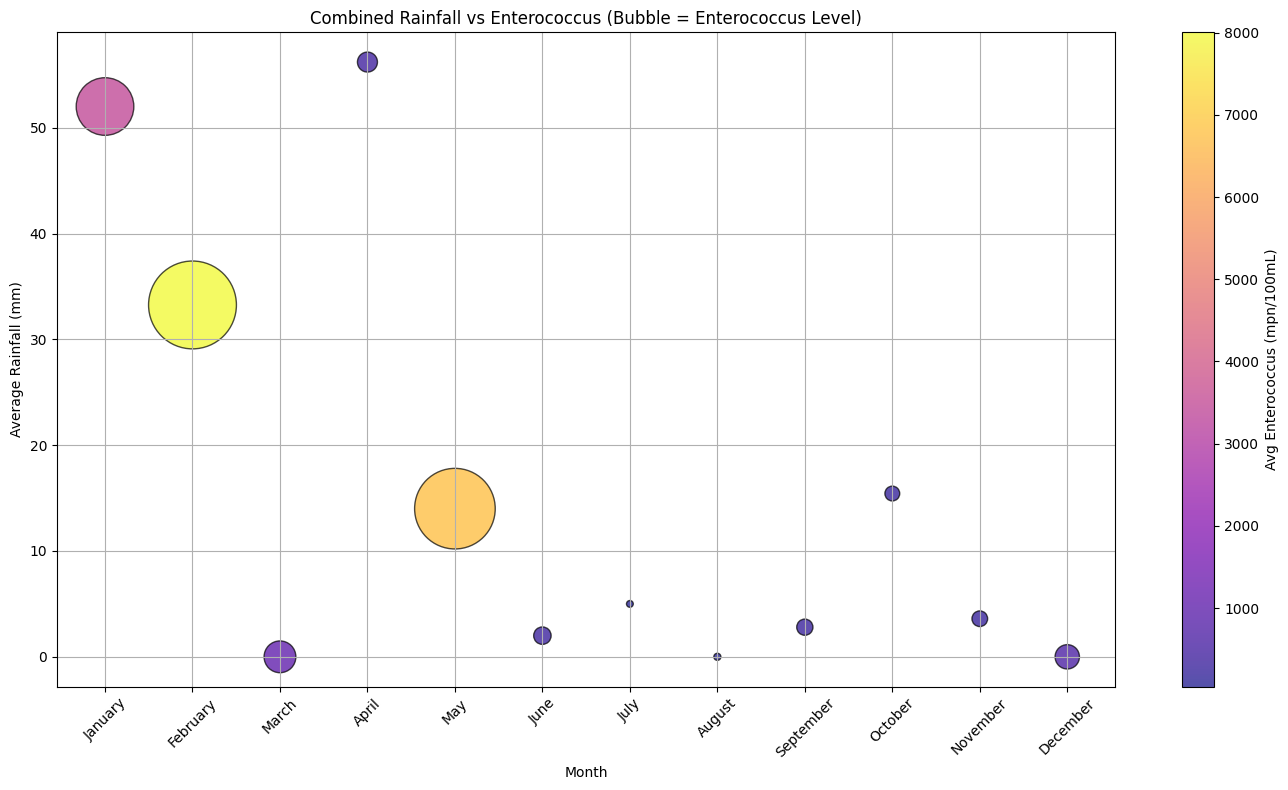

In [44]:
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    bubble_data_all_rain['Month'],
    bubble_data_all_rain['DlySum'],
    s=bubble_data_all_rain['Enterococcus (mpn/100mL)'] * 0.5,
    c=bubble_data_all_rain['Enterococcus (mpn/100mL)'],
    cmap='plasma',
    alpha=0.7,
    edgecolors='black',
    marker='o'
)

cbar = plt.colorbar(scatter)
cbar.set_label('Avg Enterococcus (mpn/100mL)')

plt.xticks(rotation=45)
plt.title("Combined Rainfall vs Enterococcus (Bubble = Enterococcus Level)")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
rain_dfs = [camp_df, makaha_df, opaeula_df, tantalus_df, waialua_df]

for i in range(len(rain_dfs)):
    df = rain_dfs[i]
    df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
    df['DlySum'] = pd.to_numeric(df['DlySum'], errors='coerce')
    df.dropna(subset=['DATE', 'DlySum'], inplace=True)
    df = df[df['DlySum'] >= 0]
    rain_dfs[i] = df

combined_rainfall = pd.concat(rain_dfs, ignore_index=True)
daily_rainfall = combined_rainfall.groupby('DATE')['DlySum'].sum().reset_index()

kaupuni_df = pd.read_csv("Kaupuni(Main).csv")
kaupuni_df['collection date'] = pd.to_datetime(kaupuni_df['collection date'], errors='coerce')
kaupuni_df['Enterococcus (mpn/100mL)'] = pd.to_numeric(kaupuni_df['Enterococcus (mpn/100mL)'], errors='coerce')
enterococcus_cleaned = kaupuni_df[['collection date', 'Enterococcus (mpn/100mL)']].dropna()
enterococcus_cleaned.rename(columns={'collection date': 'DATE'}, inplace=True)

merged_df = pd.merge(enterococcus_cleaned, daily_rainfall, on='DATE', how='inner')
merged_df['Month'] = merged_df['DATE'].dt.month_name()
merged_df['Season'] = merged_df['DATE'].dt.month.apply(lambda m: 'Rainy' if m in [11, 12, 1, 2, 3] else 'Dry')

In [48]:
bubble_data = merged_df.groupby('Month').agg({
    'DlySum': 'mean',
    'Enterococcus (mpn/100mL)': 'mean'
}).reset_index()

bubble_data['MonthOrder'] = pd.to_datetime(bubble_data['Month'], format='%B').dt.month
bubble_data.sort_values('MonthOrder', inplace=True)

season_avg = merged_df.groupby('Season')['Enterococcus (mpn/100mL)'].mean().reset_index()

correlation = merged_df[['DlySum', 'Enterococcus (mpn/100mL)']].corr().iloc[0, 1]


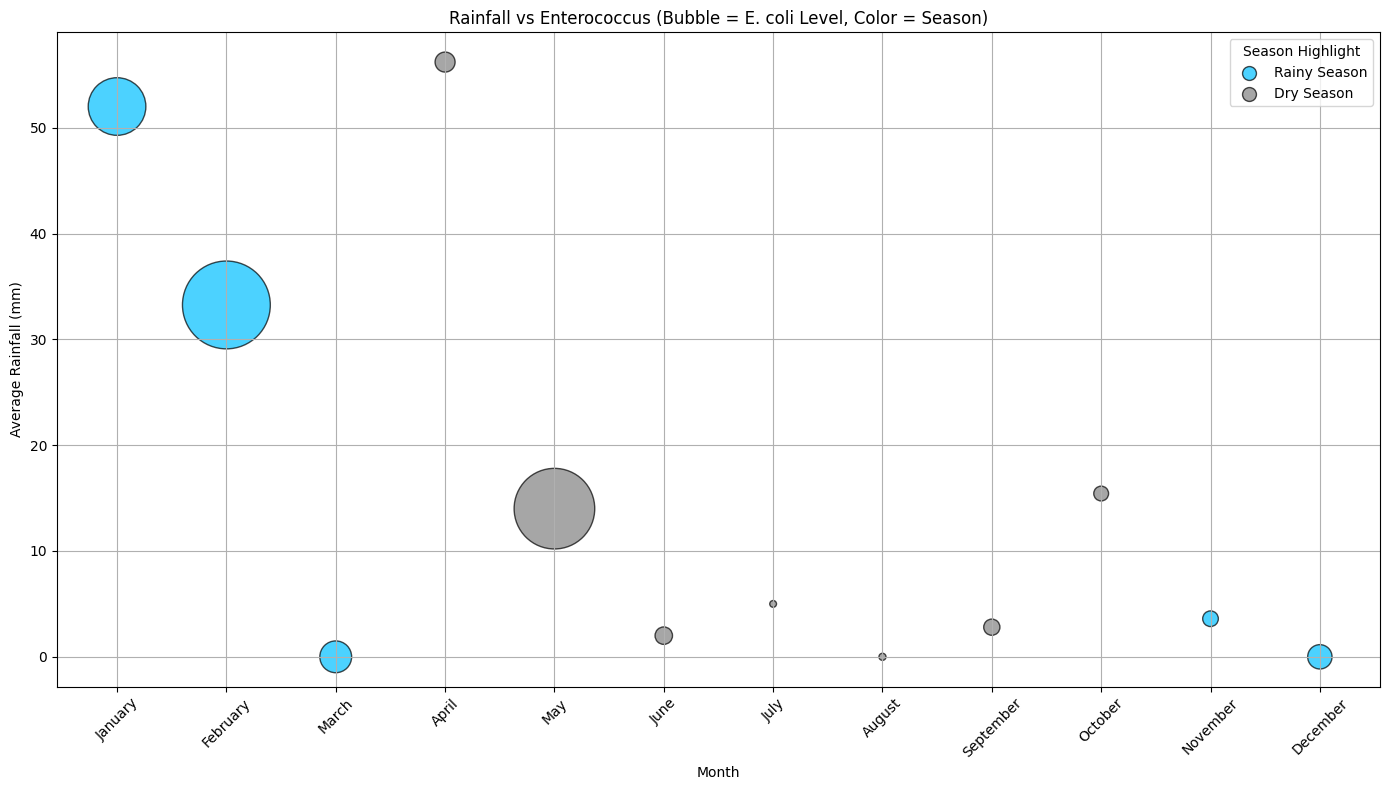

Seasonal Averages:
   Season  Enterococcus (mpn/100mL)
0    Dry               1116.833333
1  Rainy               2762.578947

Correlation between daily rainfall and Enterococcus: 0.016


In [30]:
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    bubble_data['Month'],
    bubble_data['DlySum'],
    s=bubble_data['Enterococcus (mpn/100mL)'] * 0.5,
    c=bubble_data['MonthOrder'].apply(lambda m: 'deepskyblue' if m in [11, 12, 1, 2, 3] else 'gray'),
    alpha=0.7,
    edgecolors='black',
    marker='o'
)

legend_handles = [
    plt.scatter([], [], s=100, facecolors='deepskyblue', edgecolors='black', alpha=0.7, label='Rainy Season'),
    plt.scatter([], [], s=100, facecolors='gray', edgecolors='black', alpha=0.7, label='Dry Season')
]

plt.legend(handles=legend_handles, title='Season Highlight', loc='upper right')
plt.xticks(rotation=45)
plt.title("Rainfall vs Enterococcus (Bubble = E. coli Level, Color = Season)")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Seasonal Averages:\n", season_avg)
print(f"\nCorrelation between daily rainfall and Enterococcus: {correlation:.3f}")
